### Astrostatistics lecture 3 

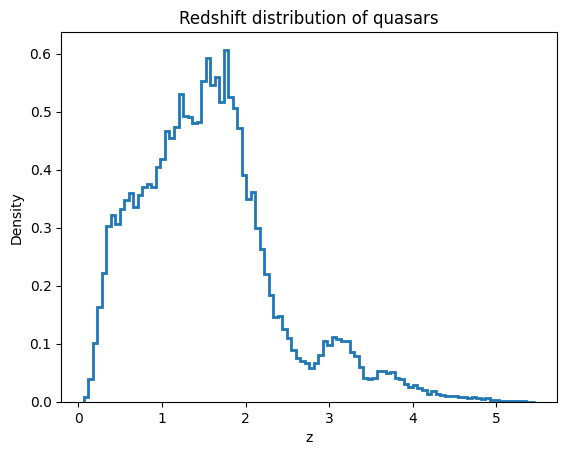

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
#loading the file with the data 
z= np.loadtxt('dr7qso.dat',skiprows=80, usecols=3)
plt.title('Redshift distribution of quasars')
plt.hist(z,bins=100,density=True,histtype='step',lw=2);
plt.xlabel('z')
plt.ylabel('Density')
plt.show()
#with this distribution we will use both rejection sampling and inverse transform sampling to generate random numbers with this distribution

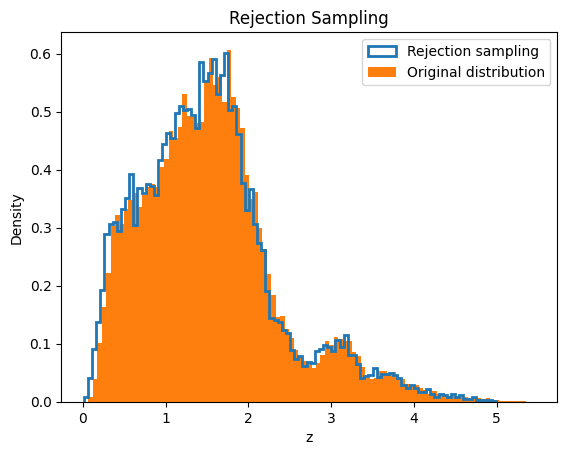

In [2]:
#firts we use the rejection sampling method
#we generate random numbers uniformly distributed between 0 and 5, which is the range of our distribution
x = np.random.uniform(0,5,100000)
#we generate random numbers uniformly distributed between 0 and the maximum of our distribution, which is around 0.6
y = np.random.uniform(0,0.6,100000)
#we evaluate the distribution at the random numbers we generated
f = np.histogram(z,bins=100,density=True)[0]
#we keep only the random numbers that are below the distribution
x_rej = x[y<f[np.digitize(x, np.histogram(z,bins=100)[1])]]
#we plot the histogram of the random numbers we kept
plt.title('Rejection Sampling')
plt.hist(x_rej,bins=100,density=True,histtype='step',lw=2, label='Rejection sampling')
plt.hist(z,bins=100,density=True,histtype='bar',lw=1,label='Original distribution', linestyle='dashed')
plt.legend()  
plt.xlabel('z')
plt.ylabel('Density')
plt.show()


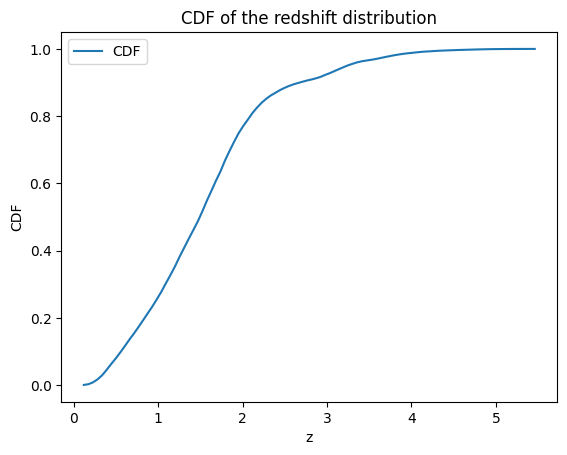

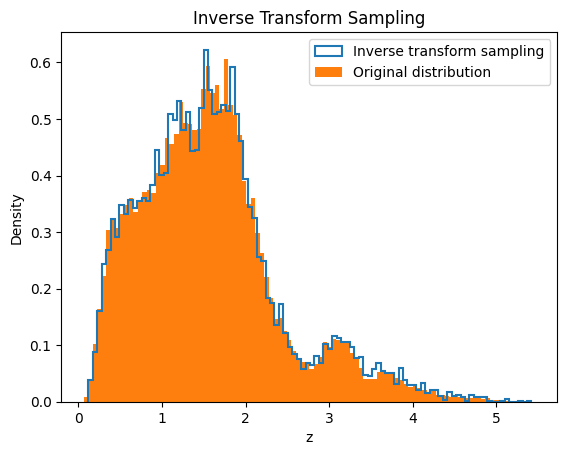

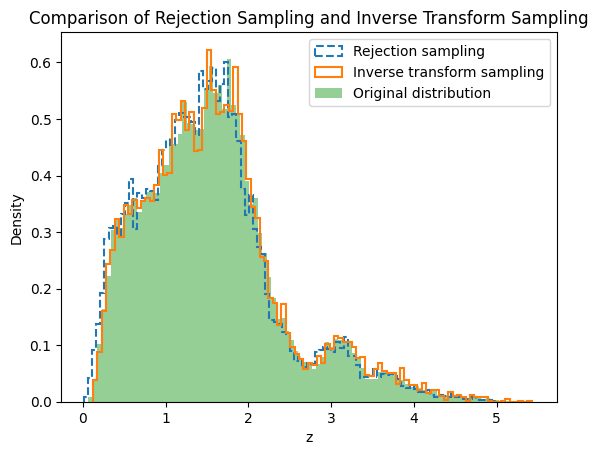

In [41]:
#then we can try it using the inverse transform sampling method
#we can use a uniform distribution to generate random numbers between 0 and 1
#then we need the CDF of our distribution, which we can get by integrating the histogram of our data
hist, bin_edges = np.histogram(z, bins=100, density=True)
cdf = np.cumsum(hist*np.diff(bin_edges))
cdf /= cdf[-1]  # normalize the CDF
#plot the CDF
plt.title('CDF of the redshift distribution')
plt.plot(bin_edges[1:], cdf, label='CDF')
plt.xlabel('z')
plt.ylabel('CDF')
plt.legend()
plt.show()

samples = []

u = np.random.uniform(0, 1, 10000) #generate 10000 random numbers uniformly distributed between 0 and 1
for ui in u:
    #we need to find the value z where CDF(z) = ui, which is equivalent to finding the root of the equation CDF(z) - ui = 0
    #to do it we need to be sure that the interpolation is bigger than ui and ui has to be bigger than the minimum interpolation value
    #sennò sto coso sfasa e non fa l'interpolazione quindi non inverte la funzione (basta mettere un if di controllo)
    if ui > cdf[-1] or ui < cdf[0]:
        continue
    z_sample = brentq(lambda z: np.interp(z, bin_edges[1:], cdf) - ui, bin_edges[1], bin_edges[-1])
    samples.append(z_sample)

#we plot the histogram of the random numbers we generated using the inverse transform sampling method
plt.title('Inverse Transform Sampling')
plt.hist(samples,bins=100,density=True,histtype='step',lw=1.5, label='Inverse transform sampling')
plt.hist(z,bins=100,density=True,histtype='bar',lw=1,label='Original distribution', linestyle='dashed')
plt.legend()
plt.xlabel('z')
plt.ylabel('Density')
plt.show()

#finally a comparison of the two methods
plt.title('Comparison of Rejection Sampling and Inverse Transform Sampling')
plt.hist(x_rej,bins=100,density=True,histtype='step',lw=1.5, label='Rejection sampling', linestyle='dashed')
plt.hist(samples,bins=100,density=True,histtype='step',lw=1.5, label='Inverse transform sampling')
plt.hist(z,bins=100,density=True,histtype='bar',lw=1,label='Original distribution', linestyle='dashed', alpha=0.5)
plt.legend()
plt.xlabel('z')
plt.ylabel('Density')
plt.show()